In [ ]:
!pip install -q imbalanced-learn xgboost

import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from google.colab import drive

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from imblearn.over_sampling import SMOTE, BorderlineSMOTE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/software_fault_paper"
DATA_DIR = f"{BASE_DIR}/data/PROMISE-backup/bug-data"
OUTPUT_DIR = f"{BASE_DIR}/outputs"

os.makedirs(f"{OUTPUT_DIR}/results", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/tables", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/figures", exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(f"DATA_DIR not found: {DATA_DIR}")

Mounted at /content/drive
DATA_DIR: /content/drive/MyDrive/software_fault_paper/data/PROMISE-backup/bug-data
OUTPUT_DIR: /content/drive/MyDrive/software_fault_paper/outputs


In [ ]:
csv_files = sorted(glob.glob(DATA_DIR + "/**/*.csv", recursive=True))

print("Total CSV files found:", len(csv_files))
for f in csv_files[:10]:
    print(f)

selected_dataset_names = [
    "ant-1.3",
    "camel-1.0",
    "jedit-3.2",
    "log4j-1.0",
    "lucene-2.0",
    "poi-1.5",
    "synapse-1.0",
    "velocity-1.5",
    "xalan-2.4",
    "xerces-1.2"
]

selected_files = [
    f for f in csv_files
    if os.path.basename(f).replace(".csv", "") in selected_dataset_names
]

print("\nSelected files:", len(selected_files))
for f in selected_files:
    print(f)

if len(selected_files) == 0:
    raise ValueError("No selected dataset files found. Check DATA_DIR and dataset names.")

Total CSV files found: 41
/content/drive/MyDrive/software_fault_paper/data/PROMISE-backup/bug-data/ant/ant-1.3.csv
/content/drive/MyDrive/software_fault_paper/data/PROMISE-backup/bug-data/ant/ant-1.4.csv
/content/drive/MyDrive/software_fault_paper/data/PROMISE-backup/bug-data/ant/ant-1.5.csv
/content/drive/MyDrive/software_fault_paper/data/PROMISE-backup/bug-data/ant/ant-1.6.csv
/content/drive/MyDrive/software_fault_paper/data/PROMISE-backup/bug-data/ant/ant-1.7.csv
/content/drive/MyDrive/software_fault_paper/data/PROMISE-backup/bug-data/camel/camel-1.0.csv
/content/drive/MyDrive/software_fault_paper/data/PROMISE-backup/bug-data/camel/camel-1.2.csv
/content/drive/MyDrive/software_fault_paper/data/PROMISE-backup/bug-data/camel/camel-1.4.csv
/content/drive/MyDrive/software_fault_paper/data/PROMISE-backup/bug-data/camel/camel-1.6.csv
/content/drive/MyDrive/software_fault_paper/data/PROMISE-backup/bug-data/ivy/ivy-1.0.csv

Selected files: 10
/content/drive/MyDrive/software_fault_paper/data

In [ ]:
def detect_label_column(df):
    possible_labels = [
        "bug", "bugs", "defect", "defects",
        "fault", "faults", "label", "class"
    ]

    for col in df.columns:
        if col.strip().lower() in possible_labels:
            return col

    # fallback: search partial names
    for col in df.columns:
        lc = col.strip().lower()
        if "bug" in lc or "defect" in lc or "fault" in lc:
            return col

    raise ValueError(f"No label column found. Columns are: {df.columns.tolist()}")


def load_dataset(file_path):
    df = pd.read_csv(file_path)
    df.columns = [str(c).strip() for c in df.columns]

    label_col = detect_label_column(df)

    y_raw = df[label_col]

    if y_raw.dtype == "object":
        y = (
            y_raw.astype(str)
            .str.strip()
            .str.lower()
            .map({
                "true": 1,
                "false": 0,
                "yes": 1,
                "no": 0,
                "buggy": 1,
                "clean": 0,
                "faulty": 1,
                "non-faulty": 0,
                "nonfaulty": 0
            })
        )

        if y.isna().sum() > 0:
            y = pd.to_numeric(y_raw, errors="coerce")
    else:
        y = pd.to_numeric(y_raw, errors="coerce")

    y = y.fillna(0)
    y = (y > 0).astype(int)

    X = df.drop(columns=[label_col])

    # Keep only numerical software metrics
    X_numeric = X.select_dtypes(include=[np.number]).copy()

    # Remove columns with all missing values
    X_numeric = X_numeric.dropna(axis=1, how="all")

    if X_numeric.shape[1] == 0:
        raise ValueError(f"No numeric feature columns found in {file_path}")

    return X_numeric, y, df, label_col

In [ ]:
def match_metric_columns(columns, keys):
    matched = []

    for col in columns:
        lc = str(col).lower()

        for key in keys:
            key = key.lower()

            if len(key) <= 4:
                if (
                    lc == key
                    or lc.startswith(key + "_")
                    or lc.endswith("_" + key)
                    or ("_" + key + "_") in lc
                ):
                    matched.append(col)
            else:
                if key in lc:
                    matched.append(col)

    return list(dict.fromkeys(matched))


def generate_pseudo_postmortem_v3(row, q75, q90, q25):
    phrases = []
    risk_score = 0

    metric_groups = {
        "size": {
            "keys": ["loc", "nloc", "npm"],
            "phrase": "large module size"
        },
        "complexity": {
            "keys": ["wmc", "max_cc", "avg_cc", "cyclomatic", "complexity", "amc"],
            "phrase": "high code complexity"
        },
        "coupling": {
            "keys": ["cbo", "rfc", "ca", "ce", "cbm", "ic"],
            "phrase": "high coupling and dependency interaction"
        },
        "cohesion": {
            "keys": ["lcom", "lcom3"],
            "phrase": "low cohesion among methods"
        },
        "inheritance": {
            "keys": ["dit", "noc", "mfa", "moa"],
            "phrase": "inheritance-related structural risk"
        }
    }

    for group_name, group_info in metric_groups.items():
        matched_cols = match_metric_columns(row.index, group_info["keys"])

        if len(matched_cols) == 0:
            continue

        high_cols = [col for col in matched_cols if row[col] >= q75.get(col, np.inf)]
        very_high_cols = [col for col in matched_cols if row[col] >= q90.get(col, np.inf)]

        high_ratio = len(high_cols) / max(len(matched_cols), 1)

        if len(very_high_cols) > 0 or high_ratio >= 0.50:
            selected_cols = very_high_cols[:3] if len(very_high_cols) > 0 else high_cols[:3]

            if len(very_high_cols) > 0:
                severity = "very high"
                risk_score += 2
            else:
                severity = "high"
                risk_score += 1

            metric_names = ", ".join(selected_cols)
            phrases.append(
                f"{group_info['phrase']} indicated by {severity} values of {metric_names}"
            )

    weak_quality_metrics = match_metric_columns(row.index, ["dam", "cam"])

    if len(weak_quality_metrics) > 0:
        low_cols = [col for col in weak_quality_metrics if row[col] <= q25.get(col, -np.inf)]
        low_ratio = len(low_cols) / max(len(weak_quality_metrics), 1)

        if low_ratio >= 0.50:
            metric_names = ", ".join(low_cols[:3])
            phrases.append(
                f"weak encapsulation or abstraction indicated by low values of {metric_names}"
            )
            risk_score += 1

    if risk_score >= 5:
        risk_level = "high"
    elif risk_score >= 3:
        risk_level = "medium"
    elif risk_score >= 1:
        risk_level = "low to medium"
    else:
        risk_level = "low"

    if len(phrases) == 0:
        return (
            "The module shows stable software metric behavior with no dominant structural risk pattern. "
            "The estimated fault risk is low."
        )

    return (
        f"The module shows {'; '.join(phrases)}. "
        f"The estimated fault risk is {risk_level}. "
        f"This module should be considered for targeted testing and code review."
    )


def create_reports_from_thresholds(X, q75, q90, q25):
    reports = X.apply(
        lambda row: generate_pseudo_postmortem_v3(row, q75, q90, q25),
        axis=1
    )
    return reports

In [ ]:
def generate_risk_features_from_thresholds(X, q75, q90, q25):
    feature_rows = []

    for _, row in X.iterrows():
        risk = {
            "risk_score": 0.0,
            "risk_factor_count": 0,
            "high_size": 0,
            "high_complexity": 0,
            "high_coupling": 0,
            "low_cohesion": 0,
            "inheritance_risk": 0,
            "weak_encapsulation": 0
        }

        def has_high_metric(keys):
            matched_cols = match_metric_columns(X.columns, keys)

            for col in matched_cols:
                if row[col] >= q75.get(col, np.inf) or row[col] >= q90.get(col, np.inf):
                    return 1

            return 0

        def has_low_metric(keys):
            matched_cols = match_metric_columns(X.columns, keys)

            for col in matched_cols:
                if row[col] <= q25.get(col, -np.inf):
                    return 1

            return 0

        risk["high_size"] = has_high_metric(["loc", "nloc", "npm"])
        risk["high_complexity"] = has_high_metric(["wmc", "max_cc", "avg_cc", "cyclomatic", "complexity", "amc"])
        risk["high_coupling"] = has_high_metric(["cbo", "rfc", "ca", "ce", "cbm", "ic"])
        risk["low_cohesion"] = has_high_metric(["lcom", "lcom3"])
        risk["inheritance_risk"] = has_high_metric(["dit", "noc", "mfa", "moa"])
        risk["weak_encapsulation"] = has_low_metric(["dam", "cam"])

        binary_factors = [
            risk["high_size"],
            risk["high_complexity"],
            risk["high_coupling"],
            risk["low_cohesion"],
            risk["inheritance_risk"],
            risk["weak_encapsulation"]
        ]

        risk["risk_factor_count"] = int(sum(binary_factors))

        risk["risk_score"] = (
            1.0 * risk["high_size"] +
            1.5 * risk["high_complexity"] +
            1.5 * risk["high_coupling"] +
            1.0 * risk["low_cohesion"] +
            1.0 * risk["inheritance_risk"] +
            1.0 * risk["weak_encapsulation"]
        )

        feature_rows.append(risk)

    return pd.DataFrame(feature_rows)

In [ ]:
class FoldFeatureBuilder:
    def __init__(
        self,
        feature_set,
        tfidf_max_features=150,
        tfidf_ngram_range=(1, 2),
        svd_max_components=30,
        selected_k=30,
        random_state=42
    ):
        self.feature_set = feature_set
        self.tfidf_max_features = tfidf_max_features
        self.tfidf_ngram_range = tfidf_ngram_range
        self.svd_max_components = svd_max_components
        self.selected_k = selected_k
        self.random_state = random_state

    def fit(self, X_train, y_train):
        self.q75_ = X_train.quantile(0.75).to_dict()
        self.q90_ = X_train.quantile(0.90).to_dict()
        self.q25_ = X_train.quantile(0.25).to_dict()

        # Numeric metrics preprocessing
        self.metric_imputer_ = SimpleImputer(strategy="median")
        self.metric_scaler_ = StandardScaler()

        X_num_train = self.metric_imputer_.fit_transform(X_train)
        X_num_train = self.metric_scaler_.fit_transform(X_num_train)

        self.metric_dim_ = X_num_train.shape[1]

        # Reports
        reports_train = create_reports_from_thresholds(
            X_train, self.q75_, self.q90_, self.q25_
        )

        self.tfidf_ = TfidfVectorizer(
            max_features=self.tfidf_max_features,
            ngram_range=self.tfidf_ngram_range,
            min_df=2
        )

        X_text_train_sparse = self.tfidf_.fit_transform(reports_train)

        self.use_svd_ = False
        self.svd_ = None

        if X_text_train_sparse.shape[1] > 2 and X_text_train_sparse.shape[0] > 2:
            n_components = min(
                self.svd_max_components,
                X_text_train_sparse.shape[1] - 1,
                X_text_train_sparse.shape[0] - 1
            )

            if n_components >= 1:
                self.svd_ = TruncatedSVD(
                    n_components=n_components,
                    random_state=self.random_state
                )
                X_text_train = self.svd_.fit_transform(X_text_train_sparse)
                self.use_svd_ = True
            else:
                X_text_train = X_text_train_sparse.toarray()
        else:
            X_text_train = X_text_train_sparse.toarray()

        self.text_dim_ = X_text_train.shape[1]

        # Risk features preprocessing
        X_risk_train_df = generate_risk_features_from_thresholds(
            X_train, self.q75_, self.q90_, self.q25_
        )

        self.risk_imputer_ = SimpleImputer(strategy="median")
        self.risk_scaler_ = StandardScaler()

        X_risk_train = self.risk_imputer_.fit_transform(X_risk_train_df)
        X_risk_train = self.risk_scaler_.fit_transform(X_risk_train)

        self.risk_dim_ = X_risk_train.shape[1]

        # Build selected feature selector if required
        X_combined_train = np.hstack([X_num_train, X_text_train, X_risk_train])

        self.selector_ = None

        if self.feature_set == "METRICS_POST_TFIDF_RISK_SELECTED":
            k = min(self.selected_k, X_combined_train.shape[1])

            self.selector_ = SelectKBest(
                score_func=mutual_info_classif,
                k=k
            )

            self.selector_.fit(X_combined_train, y_train)

        return self

    def transform(self, X):
        X_num = self.metric_imputer_.transform(X)
        X_num = self.metric_scaler_.transform(X_num)

        reports = create_reports_from_thresholds(
            X, self.q75_, self.q90_, self.q25_
        )

        X_text_sparse = self.tfidf_.transform(reports)

        if self.use_svd_:
            X_text = self.svd_.transform(X_text_sparse)
        else:
            X_text = X_text_sparse.toarray()

        X_risk_df = generate_risk_features_from_thresholds(
            X, self.q75_, self.q90_, self.q25_
        )

        X_risk = self.risk_imputer_.transform(X_risk_df)
        X_risk = self.risk_scaler_.transform(X_risk)

        if self.feature_set == "METRICS":
            return X_num

        if self.feature_set == "POST_TFIDF":
            return X_text

        if self.feature_set == "RISK_FEATURES":
            return X_risk

        if self.feature_set == "METRICS_RISK":
            return np.hstack([X_num, X_risk])

        if self.feature_set == "METRICS_POST_TFIDF_RISK":
            return np.hstack([X_num, X_text, X_risk])

        if self.feature_set == "METRICS_POST_TFIDF_RISK_SELECTED":
            X_combined = np.hstack([X_num, X_text, X_risk])
            return self.selector_.transform(X_combined)

        raise ValueError(f"Unknown feature_set: {self.feature_set}")

    def fit_transform(self, X_train, y_train):
        self.fit(X_train, y_train)
        return self.transform(X_train)

In [ ]:
def apply_balancing(X_train, y_train, method):
    y_train = np.asarray(y_train)

    if method == "NONE":
        return X_train, y_train

    class_counts = pd.Series(y_train).value_counts()

    if len(class_counts) < 2:
        return X_train, y_train

    minority_count = int(class_counts.min())

    if minority_count <= 2:
        return X_train, y_train

    k_neighbors = min(5, minority_count - 1)

    if method == "SMOTE":
        sampler = SMOTE(
            random_state=RANDOM_STATE,
            k_neighbors=k_neighbors
        )
        return sampler.fit_resample(X_train, y_train)

    if method == "BLSMOTE":
        m_neighbors = min(10, minority_count - 1)

        sampler = BorderlineSMOTE(
            random_state=RANDOM_STATE,
            k_neighbors=k_neighbors,
            m_neighbors=m_neighbors
        )
        return sampler.fit_resample(X_train, y_train)

    raise ValueError(f"Unknown balancing method: {method}")


classifiers = {
    "LR": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
        class_weight=None
    ),

    "RF": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "ET": ExtraTreesClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "SVM_RBF": SVC(
        kernel="rbf",
        probability=True,
        random_state=RANDOM_STATE
    ),

    "GB": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

feature_sets_to_run = [
    "METRICS",
    "POST_TFIDF",
    "RISK_FEATURES",
    "METRICS_RISK",
    "METRICS_POST_TFIDF_RISK",
    "METRICS_POST_TFIDF_RISK_SELECTED"
]

balancing_methods = ["NONE", "SMOTE", "BLSMOTE"]

print("Classifiers:", list(classifiers.keys()))
print("Feature sets:", feature_sets_to_run)
print("Balancing:", balancing_methods)

Classifiers: ['LR', 'RF', 'ET', 'SVM_RBF', 'GB']
Feature sets: ['METRICS', 'POST_TFIDF', 'RISK_FEATURES', 'METRICS_RISK', 'METRICS_POST_TFIDF_RISK', 'METRICS_POST_TFIDF_RISK_SELECTED']
Balancing: ['NONE', 'SMOTE', 'BLSMOTE']


In [ ]:
def safe_auc_score(y_true, y_prob):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_prob)
    except Exception:
        return np.nan


def evaluate_single_configuration(
    X_df,
    y,
    dataset_name,
    feature_set,
    balancing_method,
    classifier_name,
    classifier,
    n_splits=5
):
    y = pd.Series(y).reset_index(drop=True)
    X_df = X_df.reset_index(drop=True)

    class_counts = y.value_counts()

    if len(class_counts) < 2:
        return []

    min_class_count = int(class_counts.min())

    if min_class_count < 2:
        return []

    actual_splits = min(n_splits, min_class_count)

    skf = StratifiedKFold(
        n_splits=actual_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_df, y), start=1):
        X_train_df = X_df.iloc[train_idx].copy()
        X_test_df = X_df.iloc[test_idx].copy()

        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        builder = FoldFeatureBuilder(
            feature_set=feature_set,
            random_state=RANDOM_STATE
        )

        X_train = builder.fit_transform(X_train_df, y_train)
        X_test = builder.transform(X_test_df)

        X_train_bal, y_train_bal = apply_balancing(
            X_train,
            y_train,
            balancing_method
        )

        model = clone(classifier)
        model.fit(X_train_bal, y_train_bal)

        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_prob = model.decision_function(X_test)
        else:
            y_prob = y_pred

        row = {
            "dataset": dataset_name,
            "feature_set": feature_set,
            "balancing": balancing_method,
            "classifier": classifier_name,
            "fold": fold,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "auc": safe_auc_score(y_test, y_prob),
            "mcc": matthews_corrcoef(y_test, y_pred)
        }

        fold_results.append(row)

    return fold_results

In [10]:
all_results = []

for file_path in selected_files:
    dataset_name = os.path.basename(file_path).replace(".csv", "")
    print(f"\nRunning dataset: {dataset_name}")

    try:
        X_numeric, y, raw_df, label_col = load_dataset(file_path)

        print(
            f"Shape: {X_numeric.shape}, "
            f"Label column: {label_col}, "
            f"Class distribution: {dict(pd.Series(y).value_counts())}"
        )

        if pd.Series(y).nunique() < 2:
            print("Skipping because only one class exists.")
            continue

        for feature_set in feature_sets_to_run:
            for balancing_method in balancing_methods:
                for classifier_name, classifier in classifiers.items():

                    try:
                        fold_rows = evaluate_single_configuration(
                            X_df=X_numeric,
                            y=y,
                            dataset_name=dataset_name,
                            feature_set=feature_set,
                            balancing_method=balancing_method,
                            classifier_name=classifier_name,
                            classifier=classifier,
                            n_splits=5
                        )

                        all_results.extend(fold_rows)

                    except Exception as e:
                        print(
                            "Error:",
                            dataset_name,
                            feature_set,
                            balancing_method,
                            classifier_name,
                            "=>",
                            str(e)
                        )

    except Exception as e:
        print("Dataset loading error:", dataset_name, "=>", str(e))

results_df = pd.DataFrame(all_results)

print("\nTotal result rows:", len(results_df))
results_df.head()


Running dataset: ant-1.3
Shape: (125, 20), Label column: bug, Class distribution: {0: np.int64(105), 1: np.int64(20)}

Running dataset: camel-1.0
Shape: (339, 20), Label column: bug, Class distribution: {0: np.int64(326), 1: np.int64(13)}

Running dataset: jedit-3.2
Shape: (272, 20), Label column: bug, Class distribution: {0: np.int64(182), 1: np.int64(90)}

Running dataset: log4j-1.0
Shape: (135, 20), Label column: bug, Class distribution: {0: np.int64(101), 1: np.int64(34)}

Running dataset: lucene-2.0
Shape: (195, 20), Label column: bug, Class distribution: {0: np.int64(104), 1: np.int64(91)}

Running dataset: poi-1.5
Shape: (237, 20), Label column: bug, Class distribution: {1: np.int64(141), 0: np.int64(96)}

Running dataset: synapse-1.0
Shape: (157, 20), Label column: bug, Class distribution: {0: np.int64(141), 1: np.int64(16)}

Running dataset: velocity-1.5
Shape: (214, 20), Label column: bug, Class distribution: {1: np.int64(142), 0: np.int64(72)}

Running dataset: xalan-2.4
Sh

,dataset,feature_set,balancing,classifier,fold,accuracy,precision,recall,f1,auc,mcc
0,ant-1.3,METRICS,NONE,LR,1,0.88,1.000000,0.25,0.400000,0.750000,0.467707
1,ant-1.3,METRICS,NONE,LR,2,0.84,0.500000,0.25,0.333333,0.678571,0.273483
2,ant-1.3,METRICS,NONE,LR,3,0.80,0.333333,0.25,0.285714,0.880952,0.174595
3,ant-1.3,METRICS,NONE,LR,4,0.84,0.500000,0.25,0.333333,0.714286,0.273483
4,ant-1.3,METRICS,NONE,LR,5,0.76,0.250000,0.25,0.250000,0.738095,0.107143


In [11]:
full_results_path = f"{OUTPUT_DIR}/results/fold_level_results_corrected.csv"
results_df.to_csv(full_results_path, index=False)

print("Saved full results to:", full_results_path)

Saved full results to: /content/drive/MyDrive/software_fault_paper/outputs/results/fold_level_results_corrected.csv


In [12]:
summary_df = results_df.groupby(
    ["feature_set", "balancing", "classifier"],
    as_index=False
)[["accuracy", "precision", "recall", "f1", "auc", "mcc"]].mean()

summary_df = summary_df.sort_values(
    by=["f1", "mcc", "auc"],
    ascending=False
).reset_index(drop=True)

summary_path = f"{OUTPUT_DIR}/results/summary_results_corrected.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved summary to:", summary_path)

summary_df.head(30)

Saved summary to: /content/drive/MyDrive/software_fault_paper/outputs/results/summary_results_corrected.csv


,feature_set,balancing,classifier,accuracy,precision,recall,f1,auc,mcc
0,METRICS,SMOTE,RF,0.796900,0.569380,0.563265,0.547851,0.785796,0.386936
1,METRICS_RISK,BLSMOTE,RF,0.806804,0.593988,0.543867,0.546571,0.784376,0.396807
2,METRICS,BLSMOTE,GB,0.790737,0.553635,0.559480,0.540857,0.764420,0.376216
3,POST_TFIDF,SMOTE,LR,0.731619,0.480610,0.716709,0.540252,0.765049,0.371771
4,POST_TFIDF,SMOTE,SVM_RBF,0.742778,0.485319,0.665909,0.535613,0.742980,0.356437
5,METRICS,BLSMOTE,RF,0.803450,0.582006,0.537176,0.535503,0.790915,0.387255
6,METRICS_RISK,SMOTE,RF,0.799770,0.570183,0.535745,0.532516,0.789250,0.376626
7,METRICS_POST_TFIDF_RISK_SELECTED,SMOTE,SVM_RBF,0.755378,0.493573,0.628275,0.530583,0.763977,0.358255
8,POST_TFIDF,BLSMOTE,LR,0.723391,0.475165,0.699687,0.527595,0.760416,0.362064
9,POST_TFIDF,BLSMOTE,SVM_RBF,0.734142,0.482273,0.657571,0.525853,0.741870,0.354075


In [13]:
print("Feature sets available in results:")
print(summary_df["feature_set"].unique())

Feature sets available in results:
['METRICS' 'METRICS_RISK' 'POST_TFIDF' 'METRICS_POST_TFIDF_RISK_SELECTED'
 'METRICS_POST_TFIDF_RISK' 'RISK_FEATURES']


In [14]:
baseline_best = summary_df[
    summary_df["feature_set"] == "METRICS"
].sort_values(by=["f1", "mcc", "auc"], ascending=False).head(10)

proposed_best = summary_df[
    summary_df["feature_set"].isin([
        "METRICS_RISK",
        "METRICS_POST_TFIDF_RISK",
        "METRICS_POST_TFIDF_RISK_SELECTED"
    ])
].sort_values(by=["f1", "mcc", "auc"], ascending=False).head(15)

print("Best baseline metric-only models:")
display(baseline_best)

print("\nBest proposed models:")
display(proposed_best)

Best baseline metric-only models:


,feature_set,balancing,classifier,accuracy,precision,recall,f1,auc,mcc
0,METRICS,SMOTE,RF,0.796900,0.569380,0.563265,0.547851,0.785796,0.386936
2,METRICS,BLSMOTE,GB,0.790737,0.553635,0.559480,0.540857,0.764420,0.376216
5,METRICS,BLSMOTE,RF,0.803450,0.582006,0.537176,0.535503,0.790915,0.387255
10,METRICS,SMOTE,ET,0.794197,0.533428,0.543889,0.525760,0.772521,0.356204
12,METRICS,BLSMOTE,ET,0.796399,0.550460,0.527319,0.521049,0.780544,0.362284
21,METRICS,BLSMOTE,LR,0.737293,0.477063,0.606440,0.505803,0.745115,0.323590
23,METRICS,SMOTE,GB,0.774802,0.507758,0.529022,0.502090,0.757388,0.327894
24,METRICS,SMOTE,LR,0.730645,0.469380,0.605845,0.501355,0.734179,0.314685
25,METRICS,SMOTE,SVM_RBF,0.758190,0.468135,0.588496,0.499896,0.756887,0.326052
48,METRICS,BLSMOTE,SVM_RBF,0.748833,0.470577,0.551245,0.482809,0.759468,0.305232



Best proposed models:


,feature_set,balancing,classifier,accuracy,precision,recall,f1,auc,mcc
1,METRICS_RISK,BLSMOTE,RF,0.806804,0.593988,0.543867,0.546571,0.784376,0.396807
6,METRICS_RISK,SMOTE,RF,0.799770,0.570183,0.535745,0.532516,0.789250,0.376626
7,METRICS_POST_TFIDF_RISK_SELECTED,SMOTE,SVM_RBF,0.755378,0.493573,0.628275,0.530583,0.763977,0.358255
11,METRICS_POST_TFIDF_RISK_SELECTED,BLSMOTE,SVM_RBF,0.748373,0.494579,0.614954,0.524389,0.746870,0.351940
13,METRICS_POST_TFIDF_RISK_SELECTED,BLSMOTE,ET,0.796874,0.541498,0.516176,0.516445,0.757061,0.348947
14,METRICS_POST_TFIDF_RISK_SELECTED,SMOTE,RF,0.792877,0.529470,0.515844,0.511924,0.769796,0.346237
15,METRICS_RISK,BLSMOTE,GB,0.784857,0.520654,0.528269,0.510323,0.758880,0.339928
16,METRICS_POST_TFIDF_RISK,SMOTE,SVM_RBF,0.766518,0.486289,0.574214,0.509764,0.749932,0.333883
17,METRICS_RISK,SMOTE,SVM_RBF,0.767023,0.486342,0.573824,0.509561,0.749640,0.334432
18,METRICS_POST_TFIDF_RISK_SELECTED,SMOTE,LR,0.730952,0.477602,0.626554,0.508159,0.749328,0.329705


In [15]:
dataset_summary = results_df.groupby(
    ["dataset", "feature_set", "balancing", "classifier"],
    as_index=False
)[["accuracy", "precision", "recall", "f1", "auc", "mcc"]].mean()

dataset_best = dataset_summary.sort_values(
    by=["dataset", "f1", "mcc", "auc"],
    ascending=[True, False, False, False]
).groupby("dataset").head(5)

dataset_best_path = f"{OUTPUT_DIR}/results/dataset_wise_best_results.csv"
dataset_best.to_csv(dataset_best_path, index=False)

print("Saved dataset-wise best results to:", dataset_best_path)
dataset_best.head(30)

Saved dataset-wise best results to: /content/drive/MyDrive/software_fault_paper/outputs/results/dataset_wise_best_results.csv


,dataset,feature_set,balancing,classifier,accuracy,precision,recall,f1,auc,mcc
44,ant-1.3,METRICS_POST_TFIDF_RISK_SELECTED,SMOTE,SVM_RBF,0.816000,0.496667,0.750000,0.578816,0.802381,0.503787
34,ant-1.3,METRICS_POST_TFIDF_RISK_SELECTED,BLSMOTE,SVM_RBF,0.800000,0.466667,0.800000,0.569841,0.771429,0.503261
89,ant-1.3,RISK_FEATURES,SMOTE,SVM_RBF,0.784000,0.447619,0.850000,0.567677,0.804762,0.507159
62,ant-1.3,POST_TFIDF,BLSMOTE,LR,0.784000,0.439394,0.850000,0.562222,0.797619,0.502052
77,ant-1.3,RISK_FEATURES,BLSMOTE,LR,0.776000,0.442491,0.850000,0.561794,0.791667,0.500170
91,camel-1.0,METRICS,BLSMOTE,GB,0.946795,0.366667,0.300000,0.326667,0.610676,0.303221
138,camel-1.0,METRICS_RISK,BLSMOTE,RF,0.946752,0.500000,0.233333,0.313333,0.705408,0.313942
93,camel-1.0,METRICS,BLSMOTE,RF,0.955707,0.466667,0.233333,0.300000,0.714988,0.303205
103,camel-1.0,METRICS,SMOTE,RF,0.940913,0.450000,0.233333,0.290476,0.701259,0.286153
136,camel-1.0,METRICS_RISK,BLSMOTE,GB,0.943898,0.440000,0.233333,0.283333,0.634219,0.281790


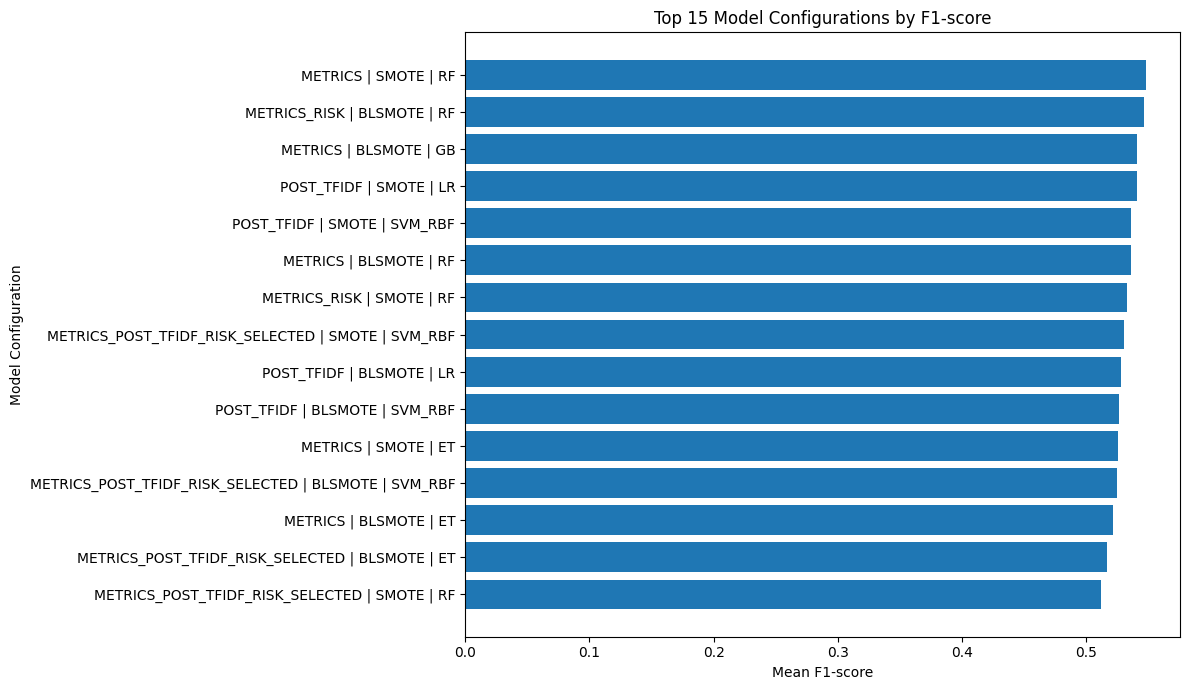

Saved figure: /content/drive/MyDrive/software_fault_paper/outputs/figures/top15_f1_corrected.png


In [16]:
import matplotlib.pyplot as plt

top15 = summary_df.head(15).copy()
top15["model"] = (
    top15["feature_set"] + " | " +
    top15["balancing"] + " | " +
    top15["classifier"]
)

plt.figure(figsize=(12, 7))
plt.barh(top15["model"][::-1], top15["f1"][::-1])
plt.xlabel("Mean F1-score")
plt.ylabel("Model Configuration")
plt.title("Top 15 Model Configurations by F1-score")
plt.tight_layout()

fig_path = f"{OUTPUT_DIR}/figures/top15_f1_corrected.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)

In [17]:
paper_table = summary_df.head(20).copy()

for col in ["accuracy", "precision", "recall", "f1", "auc", "mcc"]:
    paper_table[col] = paper_table[col].round(4)

paper_table_path = f"{OUTPUT_DIR}/tables/top20_paper_table.csv"
paper_table.to_csv(paper_table_path, index=False)

print("Saved paper table:", paper_table_path)
paper_table

Saved paper table: /content/drive/MyDrive/software_fault_paper/outputs/tables/top20_paper_table.csv


,feature_set,balancing,classifier,accuracy,precision,recall,f1,auc,mcc
0,METRICS,SMOTE,RF,0.7969,0.5694,0.5633,0.5479,0.7858,0.3869
1,METRICS_RISK,BLSMOTE,RF,0.8068,0.5940,0.5439,0.5466,0.7844,0.3968
2,METRICS,BLSMOTE,GB,0.7907,0.5536,0.5595,0.5409,0.7644,0.3762
3,POST_TFIDF,SMOTE,LR,0.7316,0.4806,0.7167,0.5403,0.7650,0.3718
4,POST_TFIDF,SMOTE,SVM_RBF,0.7428,0.4853,0.6659,0.5356,0.7430,0.3564
5,METRICS,BLSMOTE,RF,0.8034,0.5820,0.5372,0.5355,0.7909,0.3873
6,METRICS_RISK,SMOTE,RF,0.7998,0.5702,0.5357,0.5325,0.7893,0.3766
7,METRICS_POST_TFIDF_RISK_SELECTED,SMOTE,SVM_RBF,0.7554,0.4936,0.6283,0.5306,0.7640,0.3583
8,POST_TFIDF,BLSMOTE,LR,0.7234,0.4752,0.6997,0.5276,0.7604,0.3621
9,POST_TFIDF,BLSMOTE,SVM_RBF,0.7341,0.4823,0.6576,0.5259,0.7419,0.3541


In [18]:
summary_df.head(10)

,feature_set,balancing,classifier,accuracy,precision,recall,f1,auc,mcc
0,METRICS,SMOTE,RF,0.796900,0.569380,0.563265,0.547851,0.785796,0.386936
1,METRICS_RISK,BLSMOTE,RF,0.806804,0.593988,0.543867,0.546571,0.784376,0.396807
2,METRICS,BLSMOTE,GB,0.790737,0.553635,0.559480,0.540857,0.764420,0.376216
3,POST_TFIDF,SMOTE,LR,0.731619,0.480610,0.716709,0.540252,0.765049,0.371771
4,POST_TFIDF,SMOTE,SVM_RBF,0.742778,0.485319,0.665909,0.535613,0.742980,0.356437
5,METRICS,BLSMOTE,RF,0.803450,0.582006,0.537176,0.535503,0.790915,0.387255
6,METRICS_RISK,SMOTE,RF,0.799770,0.570183,0.535745,0.532516,0.789250,0.376626
7,METRICS_POST_TFIDF_RISK_SELECTED,SMOTE,SVM_RBF,0.755378,0.493573,0.628275,0.530583,0.763977,0.358255
8,POST_TFIDF,BLSMOTE,LR,0.723391,0.475165,0.699687,0.527595,0.760416,0.362064
9,POST_TFIDF,BLSMOTE,SVM_RBF,0.734142,0.482273,0.657571,0.525853,0.741870,0.354075


In [19]:
comparison_rows = summary_df[
    (
        (summary_df["feature_set"] == "METRICS") &
        (summary_df["balancing"] == "SMOTE") &
        (summary_df["classifier"] == "RF")
    )
    |
    (
        (summary_df["feature_set"] == "METRICS_RISK") &
        (summary_df["balancing"] == "BLSMOTE") &
        (summary_df["classifier"] == "RF")
    )
]

comparison_rows

,feature_set,balancing,classifier,accuracy,precision,recall,f1,auc,mcc
0,METRICS,SMOTE,RF,0.796900,0.569380,0.563265,0.547851,0.785796,0.386936
1,METRICS_RISK,BLSMOTE,RF,0.806804,0.593988,0.543867,0.546571,0.784376,0.396807


In [21]:
feature_ablation_corrected = summary_df.sort_values(
    by=["mcc", "f1", "auc"],
    ascending=False
).groupby("feature_set").head(1).reset_index(drop=True)

feature_ablation_corrected = feature_ablation_corrected[
    ["feature_set", "balancing", "classifier", "accuracy", "precision", "recall", "f1", "auc", "mcc"]
]

feature_ablation_corrected

,feature_set,balancing,classifier,accuracy,precision,recall,f1,auc,mcc
0,METRICS_RISK,BLSMOTE,RF,0.806804,0.593988,0.543867,0.546571,0.784376,0.396807
1,METRICS,BLSMOTE,RF,0.803450,0.582006,0.537176,0.535503,0.790915,0.387255
2,POST_TFIDF,SMOTE,LR,0.731619,0.480610,0.716709,0.540252,0.765049,0.371771
3,METRICS_POST_TFIDF_RISK_SELECTED,SMOTE,SVM_RBF,0.755378,0.493573,0.628275,0.530583,0.763977,0.358255
4,METRICS_POST_TFIDF_RISK,BLSMOTE,RF,0.804284,0.511796,0.516608,0.506679,0.778596,0.346636
5,RISK_FEATURES,SMOTE,LR,0.695879,0.460485,0.681433,0.503962,0.724624,0.327993


In [22]:
feature_ablation_corrected.to_csv(
    f"{OUTPUT_DIR}/tables/feature_ablation_corrected.csv",
    index=False
)